#Guilherme da Mata Garzon - NUSP 15456601

#Montagem da Matriz e informações básicas

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib as plot
import matplotlib.pyplot as plt

In [ ]:
def u_analitica(x,y):
  return np.exp(-y)*np.sin(2*np.pi*x)
#Vamos montar a matriz
def encontrar_solucao(h):
  #Definindo os índices da matriz
  n = int(1/h) - 1
  m = int(2/h) + 1
  aux = 0
  #Monta uma matriz e termo independente iniciais. A matriz é definida, inicialmente, como uma lil matrix
  #otimizada para operações ponto a ponto. Depois, será convertida em uma matriz esparsa
  M = sp.lil_matrix((n*m, n*m))
  b = np.zeros(n*m)
  X = np.linspace(h, 1 - h, n)
  #Define as constantes que serão usadas no loop, para evitar redundância
  c = 4*(np.pi)**2 - 3
  termo_neumann = -(c * h**2 + 6 * h) * np.e * np.sin(2 * np.pi * X)
  b[:n] = termo_neumann
  a = 3 + (c*h)/2
  e = 3 - (c*h)/2
  d = -8 - 6*h + c*(h**2)

  #Loop principal que coloca as entradas não nulas na matriz, baseado nas C.C e fórmula geral.
  #O loop percorre todas as linhas da matriz, que indicam as equações geradas pelos nós
  for j in range (m*n):
    i = j % n
    aux = j // n
    #Trata o caso Neumann
    if (aux == 0):
      #Neumann e Dirichlet na fronteira esquerda
      if (i == 0):
          M[j,j] = -8
          M[j,j+1] = 1
          M[j,j+n] = 6
      # Neumann e Dirichlet na fronteira direita
      elif (i == n - 1):
          M[j,j] = -8
          M[j,j-1] = 1
          M[j,j+n] = 6
      #Neumann no "interior"
      else:
          M[j,j] = -8
          M[j,j+1] = 1
          M[j,j-1] = 1
          M[j,j+n] = 6
    #Condição referente a Robin
    elif(aux == m - 1):
        #Robin com Dirichlet na fronteira esquerda
        if (i == 0):
          M[j,j] = d
          M[j,j+1] = 1
          M[j,j-n] = 6
        #Robin com Dirichlet na fronteira direita
        elif (i == n - 1):
          M[j,j] = d
          M[j,j-1] = 1
          M[j,j-n] = 6
        #Robin no "interior"
        else:
          M[j,j] = d
          M[j,j+1] = 1
          M[j,j-1] = 1
          M[j,j-n] = 6
    #Genérico
    else:
        #Dirichlet esquerdo
        if (i == 0):
          M[j,j] = -8
          M[j,j+1] = 1
          M[j,j-n] = a
          M[j,j+n] = e
        #Dirichlet direito
        elif (i == n - 1):
          M[j,j] = -8
          M[j,j-1] = 1
          M[j,j-n] = a
          M[j,j+n] = e
        #Sem Dirichlet
        else:
          M[j,j] = -8
          M[j,j-1] = 1
          M[j,j+1] = 1
          M[j,j-n] = a
          M[j,j+n] = e

  #Resolve o sistema de maneira eficiente, graças a esparcidade
  M_csr = M.tocsr()
  u = spla.spsolve(M_csr, b)
  return u

#Plotagem dos gráficos

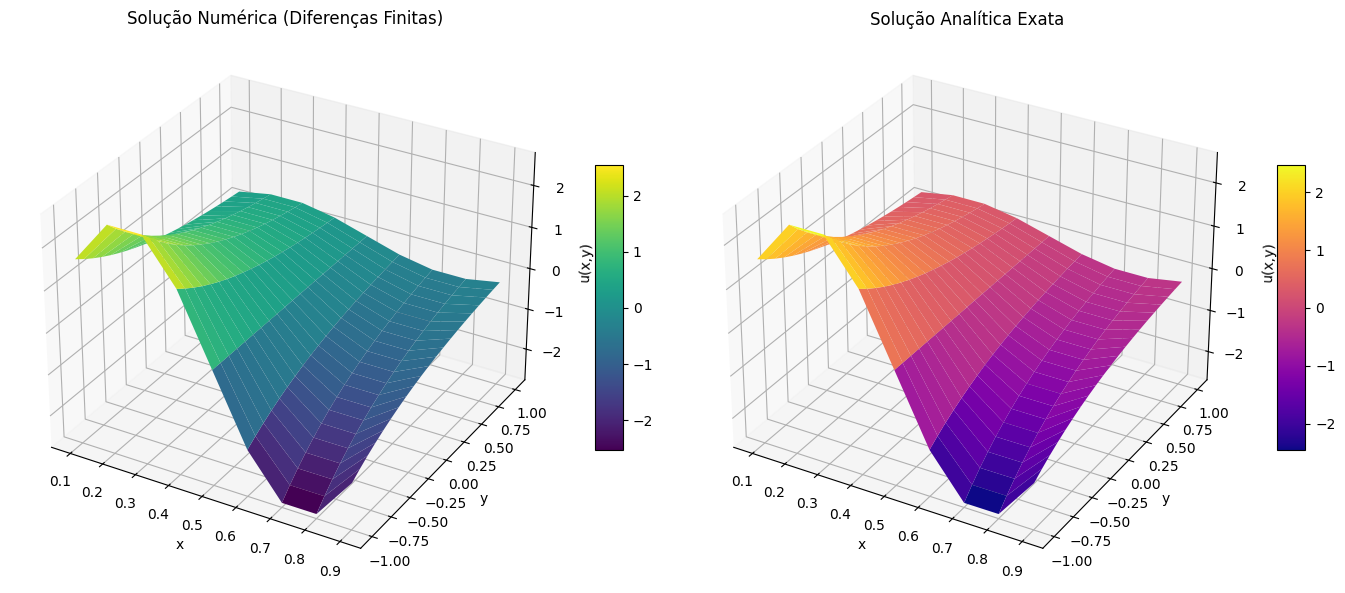

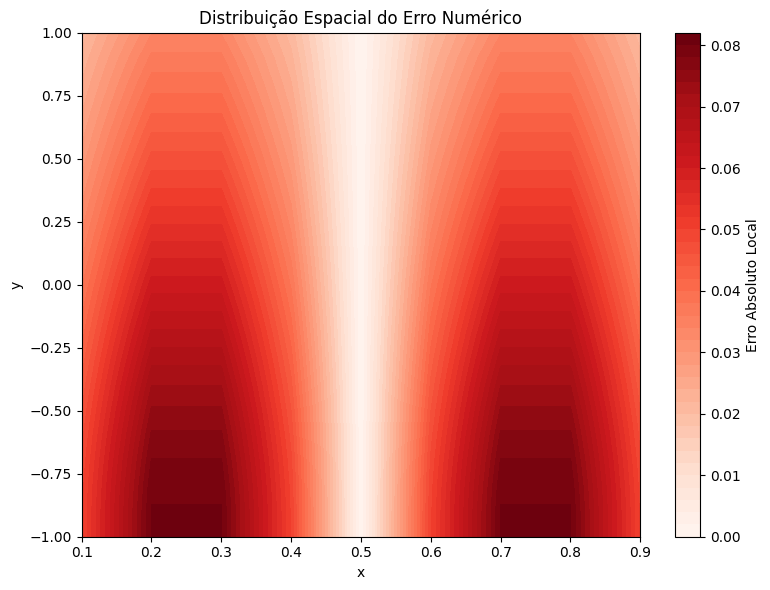

In [ ]:
h = 0.1
n = int(1/h) - 1
m = int(2/h) + 1

#Monta as listas do domínio
x_vals = np.linspace(h, 1 - h, n)
y_vals = np.linspace(-1, 1, m)

#Cria a grade 2D
X, Y = np.meshgrid(x_vals, y_vals)
U_exato = u_analitica(X, Y)

#Transforma o vetor em uma matriz
u = encontrar_solucao(h)
U_num = u.reshape((m, n))

#Cria uma figura
fig = plt.figure(figsize=(14, 6))

#Plota a solução numérica
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, U_num, cmap='viridis', edgecolor='none')
ax1.set_title('Solução Numérica (Diferenças Finitas)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u(x,y)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Plot a solução analítica
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, U_exato, cmap='plasma', edgecolor='none')
ax2.set_title('Solução Analítica Exata')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u(x,y)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

#Cria uma matriz de erros
erro_local = np.abs(U_num - U_exato)
plt.figure(figsize=(8, 6))

#Cria um mapa de calor referente aos erros
mapa_erro = plt.contourf(X, Y, erro_local, levels=50, cmap='Reds')
plt.colorbar(mapa_erro, label='Erro Absoluto Local')

plt.title('Distribuição Espacial do Erro Numérico')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

#Análise de Convergência

Ordem de convergência calculada: p = 1.9916


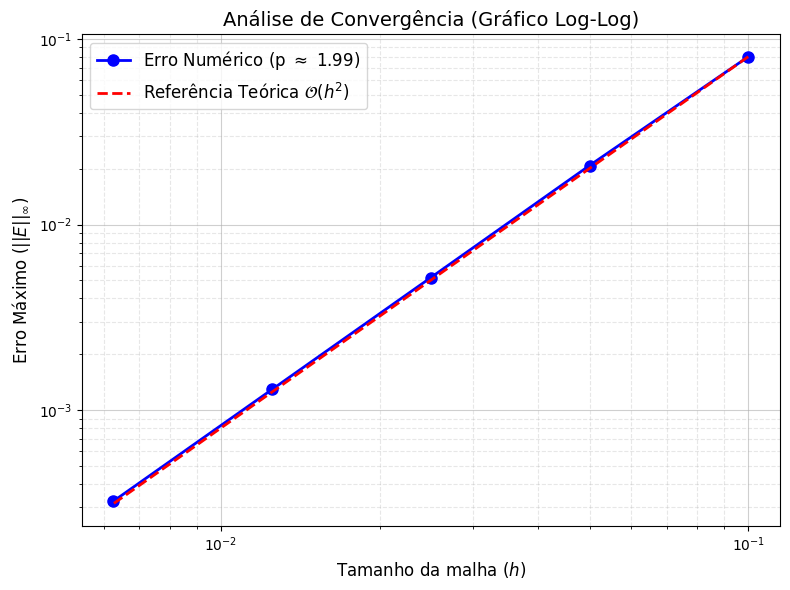

In [ ]:
#De modo geral, escolhe-se os h's
h=0.1
h_valores = []
h_valores.append(h)
for t in range(4):
 h = h/2
 h_valores.append(h)
erros = []
#Para cada h, calcula o erro máximo
for h in h_valores:
  n = int(1/h) - 1
  m = int(2/h) + 1
  x_vals = np.linspace(h, 1 - h, n)
  y_vals = np.linspace(-1, 1, m)

  X, Y = np.meshgrid(x_vals, y_vals)
  U_exato = u_analitica(X, Y)

  u = encontrar_solucao(h)
  U_num = u.reshape((m, n))

  erro_atual = np.max(np.abs(U_num - U_exato))

  erros.append(erro_atual)

#Converter as listas para arrays do numpy
h_array = np.array(h_valores)
erros_array = np.array(erros)

#Calcula a ordem de convergência a partir do coeficiente angular
#da reta log log
p = np.polyfit(np.log(h_array), np.log(erros_array), 1)[0]
print(f"Ordem de convergência calculada: p = {p:.4f}")

#Cria a reta com o erro teórico O(h^2)
referencia_h2 = erros_array[0] * (h_array / h_array[0])**2

#Faz o plot dos gráficos
plt.figure(figsize=(8, 6))

#Plot dos erros numéricos (Azul pontilhada)
plt.loglog(h_array, erros_array, marker='o', linestyle='-', color='blue',
           linewidth=2, markersize=8, label=f'Erro Numérico (p $\\approx$ {p:.2f})')

#Plot da referência teórica (vermelha tracejada)
plt.loglog(h_array, referencia_h2, linestyle='--', color='red',
           linewidth=2, label='Referência Teórica $\\mathcal{O}(h^2)$')

#Formatação
plt.title('Análise de Convergência (Gráfico Log-Log)', fontsize=14)
plt.xlabel('Tamanho da malha ($h$)', fontsize=12)
plt.ylabel('Erro Máximo ($||E||_\\infty$)', fontsize=12)

#Grid logarítmico para facilitar a leitura
plt.grid(True, which="major", linestyle='-', alpha=0.6)
plt.grid(True, which="minor", linestyle='--', alpha=0.3)

plt.legend(fontsize=12)


#Mostra o gráfico
plt.tight_layout()
plt.show()